# AeroSims: How a Flight Simulator Works
### A Ground-Up Explainer for Non-Aerospace Engineers

This notebook walks through every physical and mathematical building block behind the AeroSims React flight simulator — atmosphere, aerodynamics, forces, numerical integration, PID control, and the simulation loop — with runnable Python examples and plots at each step.

**What you'll build intuition for:**
1. Standard atmosphere — air gets thinner with altitude
2. Lift & drag — how wings work in 60 seconds of math
3. Equations of motion — Newton's second law for a flying point mass
4. Numerical integration — turning differential equations into a spreadsheet
5. PID control — the math behind "hold this altitude"
6. Propulsion — why engines lose power at altitude
7. The full loop — how it all connects in AeroSims

No aerospace background required. High-school physics + basic calculus is enough.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

---
## Part 1 — The Standard Atmosphere

Air isn't uniform. As you climb, it gets colder, less dense, and lower pressure. This matters because:
- **Lift** depends on air density
- **Drag** depends on air density  
- **Engine power** depends on air density
- **Speed of sound** depends on temperature

AeroSims uses the **International Standard Atmosphere (ISA)** — a globally-agreed mathematical model that defines how temperature, pressure, and density change with altitude.

### The Troposphere (sea level → 11 km / 36,000 ft)

Temperature drops linearly — a *lapse rate* of 6.5 K per 1000 m:

$$T(h) = T_0 - L \cdot h \quad \text{where } T_0 = 288.15\,\text{K},\; L = 0.0065\,\text{K/m}$$

Pressure follows from hydrostatics (air has weight that squeezes the air below it):

$$P(h) = P_0 \left(\frac{T(h)}{T_0}\right)^{\frac{g}{R\,L}}$$

Density comes from the ideal gas law $\rho = P / (R\,T)$.

### The Stratosphere (above 11 km)

Temperature stops changing (isothermal layer at −56.5 °C). Pressure falls exponentially:

$$P(h) = P_{11\text{km}} \cdot \exp\!\left(\frac{-g(h - 11000)}{R\,T_{11\text{km}}}\right)$$

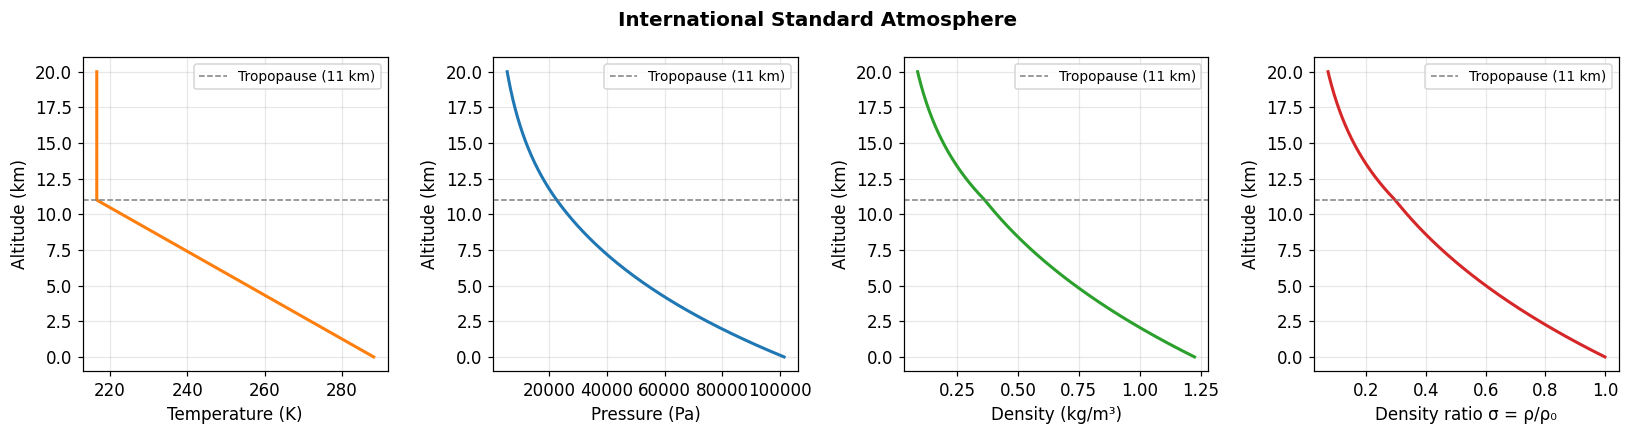

  Altitude   Temp (°C)   Density (kg/m³)   σ (density ratio)   Speed of sound
---------------------------------------------------------------------------
                Sea level       15.0°C           1.2250             1.0000         340.3 m/s
 5,000 ft (Cessna cruise)        5.1°C           1.0556             0.8617         334.4 m/s
                10,000 ft       -4.8°C           0.9046             0.7385         328.4 m/s
     35,000 ft (airliner)      -54.3°C           0.3796             0.3099         296.5 m/s


In [2]:
def isa_atmosphere(altitude_m):
    """International Standard Atmosphere — mirrors physics/atmosphere.ts"""
    g  = 9.80665   # m/s²
    R  = 287.05    # J/(kg·K)
    T0 = 288.15    # K  (15 °C at sea level)
    P0 = 101325.0  # Pa
    L  = 0.0065    # K/m  temperature lapse rate
    H_tropo = 11000.0  # m  tropopause height

    if altitude_m <= H_tropo:
        T = T0 - L * altitude_m
        P = P0 * (T / T0) ** (g / (R * L))
    else:
        T_tropo = T0 - L * H_tropo
        P_tropo = P0 * (T_tropo / T0) ** (g / (R * L))
        T = T_tropo
        P = P_tropo * np.exp(-g * (altitude_m - H_tropo) / (R * T_tropo))

    rho = P / (R * T)
    a   = np.sqrt(1.4 * R * T)   # speed of sound
    sigma = rho / 1.225           # density ratio vs sea level
    return {'T': T, 'P': P, 'rho': rho, 'a': a, 'sigma': sigma}

altitudes = np.linspace(0, 20000, 500)
atm = [isa_atmosphere(h) for h in altitudes]

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
props = [
    ('T', 'Temperature (K)', 'tab:orange'),
    ('P', 'Pressure (Pa)', 'tab:blue'),
    ('rho', 'Density (kg/m³)', 'tab:green'),
    ('sigma', 'Density ratio σ = ρ/ρ₀', 'tab:red'),
]
for ax, (key, label, color) in zip(axes, props):
    ax.plot([a[key] for a in atm], altitudes / 1000, color=color, lw=2)
    ax.axhline(11, ls='--', color='gray', lw=1, label='Tropopause (11 km)')
    ax.set_ylabel('Altitude (km)')
    ax.set_xlabel(label)
    ax.legend(fontsize=9)

fig.suptitle('International Standard Atmosphere', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print a quick table for reference altitudes
print(f"{'Altitude':>10}  {'Temp (°C)':>10}  {'Density (kg/m³)':>16}  {'σ (density ratio)':>18}  {'Speed of sound':>15}")
print('-' * 75)
for h_ft, label in [(0,'Sea level'), (5000,'5,000 ft (Cessna cruise)'), (10000,'10,000 ft'), (35000,'35,000 ft (airliner)')]:
    h_m = h_ft * 0.3048
    a = isa_atmosphere(h_m)
    print(f"{label:>25}  {a['T']-273.15:>9.1f}°C  {a['rho']:>15.4f}  {a['sigma']:>17.4f}  {a['a']:>12.1f} m/s")

**Key takeaway:** At 5,000 ft (AeroSims default cruise altitude), air density is about 86% of sea level. That means every aerodynamic force and the engine both produce ~14% less than they would at sea level.

---
## Part 2 — Lift and Drag: How Wings Work

A wing works by accelerating air downward. By Newton's third law, the air pushes the wing up — that's lift.

### Lift Coefficient $C_L$

Instead of computing exact airflow, aerodynamicists use **dimensionless coefficients** that capture wing shape and angle. Lift force is:

$$L = \frac{1}{2}\,\rho\,V^2\,S\,C_L \quad \text{(dynamic pressure × wing area × lift coefficient)}$$

The term $q = \frac{1}{2}\rho V^2$ is called **dynamic pressure** — it represents the kinetic energy of the oncoming air.

For a typical wing at moderate angles, $C_L$ is approximately linear in **angle of attack** $\alpha$ (how nose-up the wing is relative to oncoming air):

$$C_L = C_{L_\alpha}\,(\alpha - \alpha_0)$$

Where:
- $C_{L_\alpha} = 5.73$ /rad — how much extra lift per radian of tilt (Cessna 172)
- $\alpha_0 = -2°$ — the angle where lift is zero (slightly negative due to wing camber)
- $C_{L,\max} = 1.6$ — stall: above this, flow separates and lift collapses

### Drag Polar

There are two types of drag:
1. **Parasite drag** $C_{D_0}$ — fuselage, landing gear, antennas: always present regardless of lift
2. **Induced drag** $k\,C_L^2$ — the vortices created by generating lift: increases with lift squared

$$C_D = C_{D_0} + k\,C_L^2$$

This parabola is called the **drag polar**. The factor $k = \frac{1}{\pi\,e\,AR}$ where $e$ is wing efficiency (~0.8) and $AR$ is aspect ratio (wingspan²/area).

In [ ]:
# Cessna 172-class parameters from models/aircraft.ts
CL_alpha = 5.73    # /rad  lift curve slope
alpha0   = -0.0349 # rad  zero-lift angle of attack (-2°)
CD0      = 0.027   # parasite drag coefficient
k        = 0.05472 # induced drag factor
CL_max   = 1.6     # stall CL
S        = 16.17   # m²  wing area
mass     = 1111    # kg
g        = 9.80665 # m/s²
W        = mass * g  # N  weight

alpha_range = np.linspace(-5, 22, 300)  # degrees
alpha_rad   = np.radians(alpha_range)
CL_values   = np.clip(CL_alpha * (alpha_rad - alpha0), -0.5, CL_max)
CD_values   = CD0 + k * CL_values**2
LD_values   = CL_values / CD_values  # lift-to-drag ratio

# Mark stall
stall_alpha = np.degrees((CL_max / CL_alpha) + alpha0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# CL vs alpha
axes[0].plot(alpha_range, CL_values, 'b', lw=2)
axes[0].axvline(stall_alpha, color='red', ls='--', label=f'Stall α ≈ {stall_alpha:.1f}°')
axes[0].axhline(0, color='gray', lw=0.7)
axes[0].set_xlabel('Angle of Attack α (degrees)')
axes[0].set_ylabel('Lift Coefficient $C_L$')
axes[0].set_title('Lift Curve')
axes[0].legend()
axes[0].annotate('Linear region\n(our model lives here)', xy=(8, 0.9), fontsize=9,
                 arrowprops=dict(arrowstyle='->', color='green'),
                 xytext=(12, 0.4), color='green')

# Drag polar
axes[1].plot(CD_values, CL_values, 'g', lw=2)
best_LD_CL = np.sqrt(CD0 / k)
best_LD_CD = CD0 + k * best_LD_CL**2
axes[1].plot(best_LD_CD, best_LD_CL, 'ro', ms=8, label=f'Best L/D = {best_LD_CL/best_LD_CD:.0f}')
axes[1].set_xlabel('Drag Coefficient $C_D$')
axes[1].set_ylabel('Lift Coefficient $C_L$')
axes[1].set_title('Drag Polar  $C_D = C_{D_0} + k\,C_L^2$')
axes[1].legend()

# L/D ratio (efficiency)
axes[2].plot(alpha_range, LD_values, 'orange', lw=2)
axes[2].axvline(stall_alpha, color='red', ls='--', label='Stall')
axes[2].set_xlabel('Angle of Attack α (degrees)')
axes[2].set_ylabel('Lift / Drag Ratio')
axes[2].set_title('Aerodynamic Efficiency')
axes[2].annotate(f'Best L/D ≈ {best_LD_CL/best_LD_CD:.0f}\n→ glide ~{best_LD_CL/best_LD_CD:.0f}:1', 
                 xy=(alpha_range[np.argmax(LD_values)], np.max(LD_values)),
                 xytext=(12, 13), fontsize=9, color='orange',
                 arrowprops=dict(arrowstyle='->', color='orange'))
axes[2].legend()

plt.suptitle('Cessna 172-class Aerodynamics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# What CL do we need for level flight at cruise?
atm_cruise = isa_atmosphere(1524)  # 5000 ft
V_cruise   = 56.6  # m/s (110 kts)
q_cruise   = 0.5 * atm_cruise['rho'] * V_cruise**2
CL_level   = W / (q_cruise * S)
alpha_level = np.degrees(CL_level / CL_alpha + alpha0)
print(f"At cruise (5000 ft, 110 kts):")
print(f"  Dynamic pressure q = {q_cruise:.1f} Pa")
print(f"  CL needed for level flight = {CL_level:.3f}")
print(f"  Angle of attack α = {alpha_level:.2f}°  (barely nose-up — feels flat!)")

<>:42: SyntaxWarning: "\," is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\,"? A raw string is also an option.
<>:42: SyntaxWarning: "\," is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\,"? A raw string is also an option.
C:\Users\chadm\AppData\Local\Temp\ipykernel_14896\2189992111.py:42: SyntaxWarning: "\," is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\,"? A raw string is also an option.
  axes[1].set_title('Drag Polar  $C_D = C_{D_0} + k\,C_L^2$')


### Why the L/D ratio matters

The **lift-to-drag ratio** (L/D ≈ 9 for this Cessna) tells you how far you glide for every meter you descend with no engine. A glider achieves L/D ≈ 40; an airliner ≈ 17. Flying at the **best L/D angle of attack** minimizes fuel burn — this is the aerodynamic "sweet spot".

---
## Part 3 — Equations of Motion: Newton's Laws for an Aircraft

AeroSims uses **3DOF (3 Degrees of Freedom) point-mass dynamics**. "Point mass" means we track one point in space (the aircraft's center of gravity) and don't model rotation about its own axes.

### State vector

The complete aircraft state at any instant is 6 numbers:

| Variable | Symbol | Meaning |
|----------|--------|---------|
| Airspeed | $V$ | How fast through the air (m/s) |
| Flight-path angle | $\gamma$ | Nose up (+) or down (−) vs horizon (rad) |
| Heading | $\chi$ | Which compass direction (rad, 0 = North) |
| North position | $N$ | Meters north of start |
| East position | $E$ | Meters east of start |
| Down position | $D$ | Meters below start (negative = climbing) |

### Equations of Motion

These are Newton's second law ($F = ma$) written for each component of motion:

**Along-path (accelerate/decelerate):**
$$\dot{V} = \frac{T\cos\alpha - D}{m} - g\sin\gamma$$
Thrust pushes forward, drag resists, gravity pulls back when climbing.

**Cross-path vertical (pitch up/down):**
$$\dot{\gamma} = \frac{(L + T\sin\alpha)\cos\mu - mg\cos\gamma}{mV}$$
Lift (plus a bit of thrust component) curves the path upward; gravity pulls it flat.

**Cross-path lateral (turn):**
$$\dot{\chi} = \frac{(L + T\sin\alpha)\sin\mu}{mV\cos\gamma}$$
The **bank angle** $\mu$ tilts lift sideways to turn. A banked aircraft is literally redirecting its lift vector.

**Position kinematics** (velocity → position by integration):
$$\dot{N} = V\cos\gamma\cos\chi, \quad \dot{E} = V\cos\gamma\sin\chi, \quad \dot{D} = -V\sin\gamma$$

### Control inputs

The pilot (or autopilot) commands:
- **Throttle** $\delta_T$ (0–1) → sets thrust $T$
- **Normal load factor** $N_{zb}$ → sets how hard the wing bends the flight path (1.0 = level flight)
- **Bank angle** $\mu$ → sets turn rate

In [ ]:
def compute_aero_coefficients(V, rho, Nzb, CL_alpha=5.73, alpha0=-0.0349, CD0=0.027, k=0.05472, CL_max=1.6):
    """Solve for CL given body-axis load factor — mirrors physics/aerodynamics.ts
    
    Nzb (normal body-axis load factor) is roughly 'how many g's the wing is pulling'.
    1.0 = level flight, <1.0 = unloaded, >1.0 = pulling up.
    
    The trick: CL and alpha are coupled because drag rotates into the lift direction.
    We solve iteratively (converges in ~5 steps).
    """
    q = 0.5 * rho * V**2
    CL = Nzb * W / (q * S)  # initial guess ignoring drag
    
    for _ in range(10):
        CL = np.clip(CL, -0.5, CL_max)
        alpha = CL / CL_alpha + alpha0
        CD = CD0 + k * CL**2
        # Nzb * W = L*cos(a) + D*sin(a)  →  solve for CL
        CL_new = (Nzb * W / (q * S) - CD * np.sin(alpha) / np.cos(alpha))
        if abs(CL_new - CL) < 1e-6:
            break
        CL = CL_new
    
    CL = np.clip(CL, -0.5, CL_max)
    alpha = CL / CL_alpha + alpha0
    CD = CD0 + k * CL**2
    return CL, CD, alpha


def compute_derivatives(state, controls):
    """3DOF equations of motion — mirrors physics/eom.ts"""
    V, gamma, chi, N, E, D = state
    throttle, Nzb, mu = controls
    
    # Atmosphere at current altitude
    alt_m = -D  # D is Down (negative = above start)
    atm = isa_atmosphere(alt_m)
    rho = atm['rho']
    sigma = atm['sigma']
    
    # Thrust (density-scaled piston engine)
    T_max = 2100.0  # N at sea level
    T = throttle * T_max * sigma**0.85
    
    # Aerodynamics
    CL, CD, alpha = compute_aero_coefficients(max(V, 1.0), rho, Nzb)
    q = 0.5 * rho * max(V, 1.0)**2
    L = q * S * CL
    Drag = q * S * CD
    
    # Equations of motion
    # Guard against near-vertical flight
    cos_gamma = np.sign(np.cos(gamma)) * max(abs(np.cos(gamma)), 0.01)
    
    Vdot     = (T * np.cos(alpha) - Drag) / mass - g * np.sin(gamma)
    gammadot = ((L + T * np.sin(alpha)) * np.cos(mu) / mass - g * np.cos(gamma)) / max(V, 1.0)
    chidot   = ((L + T * np.sin(alpha)) * np.sin(mu) / mass) / (max(V, 1.0) * cos_gamma)
    
    # Kinematics
    Ndot = V * np.cos(gamma) * np.cos(chi)
    Edot = V * np.cos(gamma) * np.sin(chi)
    Ddot = -V * np.sin(gamma)
    
    return np.array([Vdot, gammadot, chidot, Ndot, Edot, Ddot])


# Quick sanity check: level cruise
state0 = np.array([56.6, 0.0, 0.0, 0.0, 0.0, -1524.0])  # V, gamma, chi, N, E, D
ctrl0  = (0.65, 1.0, 0.0)  # throttle, Nzb, bank
derivs = compute_derivatives(state0, ctrl0)

print("Derivatives at cruise (throttle=0.65, Nzb=1.0, level):")
labels = ['dV/dt (m/s²)', 'dγ/dt (rad/s)', 'dχ/dt (rad/s)', 'dN/dt (m/s)', 'dE/dt (m/s)', 'dD/dt (m/s)']
for label, val in zip(labels, derivs):
    print(f"  {label:>18} = {val:+.5f}")
print("\nSmall dV/dt ≈ 0 means this throttle setting is close to trim (equilibrium speed).")

### Visualizing the force balance in level flight

In steady level flight, forces and moments are balanced:
- **Lift = Weight** (no vertical acceleration)
- **Thrust = Drag** (no longitudinal acceleration)

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_aspect('equal')
ax.axis('off')

# Aircraft silhouette (simple)
fuselage = plt.Polygon([(-1.2, 0), (1.2, 0.1), (1.2, -0.1), (-1.2, -0.2)], 
                        fc='steelblue', ec='navy', zorder=3)
wing = plt.Polygon([(-0.3, 0), (0.3, 0), (0.4, -0.05), (-0.4, -0.05)], 
                    fc='lightsteelblue', ec='navy', zorder=3, transform=ax.transData)
ax.add_patch(fuselage)

# Force arrows
arrow_kw = dict(head_width=0.15, head_length=0.1, length_includes_head=True, zorder=4)

# Lift
ax.arrow(0, 0, 0, 2.0, fc='green', ec='green', **arrow_kw)
ax.text(0.2, 1.5, 'Lift\n$L = ½ρV²SC_L$', color='green', fontsize=10, va='center')

# Weight
ax.arrow(0, -0.1, 0, -1.9, fc='red', ec='red', **arrow_kw)
ax.text(0.2, -1.0, 'Weight\n$W = mg$', color='red', fontsize=10, va='center')

# Thrust
ax.arrow(-1.3, 0.0, -1.5, 0, fc='darkorange', ec='darkorange', **arrow_kw)
ax.text(-2.2, 0.3, 'Thrust\n$T$', color='darkorange', fontsize=10, ha='center')

# Drag
ax.arrow(1.3, 0.0, 1.4, 0, fc='purple', ec='purple', **arrow_kw)
ax.text(2.3, 0.3, 'Drag\n$D = ½ρV²SC_D$', color='purple', fontsize=10, ha='center')

# Equilibrium labels
ax.text(0, 2.7, 'Level flight equilibrium:\nL = W  and  T = D', ha='center', 
        fontsize=11, fontweight='bold', color='black')

ax.set_title('Four Forces of Flight', fontsize=13, fontweight='bold', pad=5)
plt.tight_layout()
plt.show()

---
## Part 4 — Numerical Integration: Turning Math into Motion

The equations of motion give us **rates of change** (derivatives like $\dot{V}$, $\dot{\gamma}$...). But to animate the aircraft, we need **positions and velocities at each time step**.

This is numerical integration: starting from a known state, we repeatedly apply:
$$\text{state}_{\text{new}} = \text{state}_{\text{old}} + \Delta t \times \dot{\text{state}}_{\text{old}}$$

### Simple Euler Integration (the naive approach)

$$y_{n+1} = y_n + \Delta t \cdot f(y_n)$$

This is cheap but accumulates error — the slope at the start of each step is used for the whole step, even though the true slope is changing.

### Heun's Method (Modified Euler / Predictor-Corrector)

AeroSims uses **Heun's method**, which is twice as accurate for the same step size:

1. **Predict** where you'll end up using the slope at the start:
   $$\tilde{y}_{n+1} = y_n + \Delta t \cdot f(y_n) \quad (\text{slope } k_1)$$

2. **Evaluate** the slope at the predicted end:
   $$k_2 = f(\tilde{y}_{n+1})$$

3. **Correct** using the *average* of both slopes:
   $$y_{n+1} = y_n + \frac{\Delta t}{2}(k_1 + k_2)$$

This gives $O(\Delta t^3)$ local error vs $O(\Delta t^2)$ for simple Euler.

AeroSims runs at **dt = 0.05 s (20 Hz)** — fast enough to capture flight dynamics, not so fast that it bogs down the browser.

In [ ]:
def euler_step(state, controls, dt):
    """Simple Euler integration."""
    k1 = compute_derivatives(state, controls)
    return state + dt * k1


def heun_step(state, controls, dt):
    """Heun's method (Modified Euler) — mirrors physics/integrator.ts"""
    k1 = compute_derivatives(state, controls)
    state_pred = state + dt * k1
    k2 = compute_derivatives(state_pred, controls)
    return state + (dt / 2.0) * (k1 + k2)


# Demonstrate on a simple falling-ball problem where we know the exact answer
# dy/dt = -g  (free fall velocity),  y: height
# Exact: y(t) = 100 - 0.5*g*t²  (dropped from 100 m)

def freefall_deriv(state):
    pos, vel = state
    return np.array([vel, -9.81])

def euler_ff(state, dt):
    return state + dt * freefall_deriv(state)

def heun_ff(state, dt):
    k1 = freefall_deriv(state)
    k2 = freefall_deriv(state + dt * k1)
    return state + (dt/2) * (k1 + k2)

T_total = 4.0
for dt, ax_idx in [(0.5, 0), (0.1, 1)]:
    pass  # collect below

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, dt in zip(axes, [0.5, 0.1]):
    t_vals = np.arange(0, T_total + dt, dt)
    t_exact = np.linspace(0, T_total, 400)
    y_exact = 100 - 0.5 * 9.81 * t_exact**2

    s_euler = np.array([100.0, 0.0])
    s_heun  = np.array([100.0, 0.0])
    euler_pos, heun_pos = [100.0], [100.0]

    for _ in t_vals[1:]:
        s_euler = euler_ff(s_euler, dt)
        s_heun  = heun_ff(s_heun, dt)
        euler_pos.append(s_euler[0])
        heun_pos.append(s_heun[0])

    ax.plot(t_exact, y_exact, 'k', lw=2, label='Exact', zorder=3)
    ax.plot(t_vals, euler_pos, 'r--o', ms=5, label=f'Euler (dt={dt}s)')
    ax.plot(t_vals, heun_pos,  'b--s', ms=5, label=f"Heun's (dt={dt}s)")
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Height (m)')
    ax.set_title(f'Free fall — dt = {dt} s')
    ax.legend()

    final_exact = 100 - 0.5 * 9.81 * T_total**2
    print(f"dt={dt}s — Exact: {final_exact:.3f} m  |  Euler error: {abs(euler_pos[-1]-final_exact):.3f} m  |  Heun error: {abs(heun_pos[-1]-final_exact):.4f} m")

plt.suptitle("Integration Methods: Accuracy vs Step Size", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("\nHeun's method is much more accurate — especially with large time steps.")

**Key takeaway:** Heun's method reduces error dramatically at the same step size. At dt=0.05 s (AeroSims rate), both methods converge well — but Heun's gives us a safety margin for maneuvers with rapidly-changing derivatives (like sharp pull-ups or stall onset).

---
## Part 5 — The PID Controller: Automated Feedback

A **PID (Proportional-Integral-Derivative) controller** is the fundamental building block of autopilots. It computes a control output to drive a measured value toward a desired setpoint.

$$u(t) = \underbrace{K_P \cdot e}_{\text{Proportional}} + \underbrace{K_I \int_0^t e\,d\tau}_{\text{Integral}} + \underbrace{K_D \frac{de}{dt}}_{\text{Derivative}}$$

Where $e = \text{setpoint} - \text{measured}$ is the **error**.

### What each term does:

| Term | Effect | Analogy |
|------|--------|---------|
| **P** (proportional) | Output ∝ current error | Foot harder on gas when further from target |
| **I** (integral) | Accumulates past error, eliminates steady-state offset | Persistent nudge if you're always 5 mph slow |
| **D** (derivative) | Reacts to error rate of change | Braking force when you're approaching target fast |

### Anti-windup

If the aircraft is far from target for a long time, the integral term can "wind up" to huge values. When the aircraft finally reaches the setpoint, the controller overshoots badly. **Anti-windup** clamps the integral: `integral = clamp(integral, ±integral_max)`.

### AeroSims Altitude Hold: Cascaded PID

A simple single-loop PID on altitude doesn't work well for aircraft (altitude changes slowly; the inner dynamics are complex). AeroSims uses a **cascaded (nested) architecture**:

```
Altitude error (m)
    → Outer PID → γ_cmd (desired climb angle)
        → Inner P → Nzb (wing load factor command)
            → EOM → actual γ → actual altitude
```

This is far more natural for an aircraft: the outer loop flies a climb angle, the inner loop executes it via wing loading.

In [ ]:
def step_pid(config, state_dict, error, dt):
    """Stateless PID step — mirrors physics/pid.ts
    
    state_dict holds {integral, last_error, first_call} across time steps.
    Returns (output, updated_state_dict).
    """
    kP, kI, kD = config['kP'], config['kI'], config['kD']
    out_min, out_max = config['outputMin'], config['outputMax']
    imax = config['integralMax']
    
    integral = state_dict['integral'] + error * dt
    integral = np.clip(integral, -imax, imax)  # anti-windup
    
    if state_dict['first_call']:
        derivative = 0.0
    else:
        derivative = (error - state_dict['last_error']) / dt
    
    output = kP * error + kI * integral + kD * derivative
    output = np.clip(output, out_min, out_max)
    
    new_state = {'integral': integral, 'last_error': error, 'first_call': False}
    return output, new_state


# Demo: PID tuning — show effect of each gain on step response
# Simplified 1st-order system: dy/dt = -y + u  (think: altitude responding to climb rate)

def simulate_pid(kP, kI, kD, setpoint=1.0, t_end=10.0, dt=0.05):
    config = {'kP': kP, 'kI': kI, 'kD': kD, 'outputMin': -2, 'outputMax': 2, 'integralMax': 5}
    pid_state = {'integral': 0.0, 'last_error': 0.0, 'first_call': True}
    y, t = 0.0, 0.0
    t_vals, y_vals = [0.0], [0.0]
    
    while t < t_end:
        error = setpoint - y
        u, pid_state = step_pid(config, pid_state, error, dt)
        # Simple first-order plant: dy/dt = -y + u
        y = y + dt * (-y + u)
        t += dt
        t_vals.append(t)
        y_vals.append(y)
    
    return np.array(t_vals), np.array(y_vals)


fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Vary P
ax = axes[0]
for kP, color in [(0.3, 'blue'), (1.0, 'green'), (3.0, 'red'), (6.0, 'orange')]:
    t, y = simulate_pid(kP, 0, 0)
    ax.plot(t, y, color=color, label=f'kP={kP}')
ax.axhline(1.0, color='black', ls='--', lw=1)
ax.set_title('Effect of Proportional Gain (kI=0, kD=0)')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Output')
ax.legend(); ax.set_ylim(-0.2, 1.5)
ax.annotate('Higher kP → faster\nbut can oscillate', xy=(2, 1.3), fontsize=9, color='red')

# Vary I (P fixed, D=0)
ax = axes[1]
for kI, color in [(0.0, 'gray'), (0.2, 'blue'), (0.5, 'green'), (2.0, 'red')]:
    t, y = simulate_pid(1.0, kI, 0)
    ax.plot(t, y, color=color, label=f'kI={kI}')
ax.axhline(1.0, color='black', ls='--', lw=1)
ax.set_title('Effect of Integral Gain (kP=1, kD=0)')
ax.set_xlabel('Time (s)')
ax.legend(); ax.set_ylim(-0.2, 1.8)
ax.annotate('kI=0: stays below target\n(steady-state error)', xy=(7, 0.7), fontsize=9, color='gray')

# Vary D (P,I fixed)
ax = axes[2]
for kD, color in [(0.0, 'red'), (0.5, 'orange'), (1.5, 'green'), (4.0, 'blue')]:
    t, y = simulate_pid(3.0, 0.3, kD)
    ax.plot(t, y, color=color, label=f'kD={kD}')
ax.axhline(1.0, color='black', ls='--', lw=1)
ax.set_title('Effect of Derivative Gain (kP=3, kI=0.3)')
ax.set_xlabel('Time (s)')
ax.legend(); ax.set_ylim(-0.2, 1.8)
ax.annotate('Higher kD damps\novershoot', xy=(3, 0.4), fontsize=9, color='blue')

plt.suptitle('PID Tuning: Effect of Each Gain', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Now simulate AeroSims' cascaded altitude PID concept
# Outer loop: altitude error → flight path angle command
# Inner loop: FPA error → Nzb (not shown explicitly — we simplify here)

# Parameters from AeroSims eventSystem.ts altitude-pid action
kP_alt  = 0.008   # altitude error (m) → gamma_cmd (rad)
kI_alt  = 0.0003
kD_alt  = 0.04
gamma_max = np.radians(12)  # max commanded climb angle
kP_fpa  = 2.0     # FPA error → Nzb adjustment

def simulate_altitude_hold(alt_initial, alt_target, V=56.6, dt=0.05, t_end=120):
    """Simplified cascaded altitude PID — conceptual version of AeroSims logic."""
    alt_config = {
        'kP': kP_alt, 'kI': kI_alt, 'kD': kD_alt,
        'outputMin': -gamma_max, 'outputMax': gamma_max, 'integralMax': 0.1
    }
    pid_state = {'integral': 0.0, 'last_error': 0.0, 'first_call': True}
    
    alt = alt_initial
    gamma = 0.0
    t = 0.0
    t_vals = [0.0]
    alt_vals = [alt]
    gamma_vals = [0.0]
    
    while t < t_end:
        # Outer PID: altitude error → desired gamma
        alt_error = alt_target - alt
        gamma_cmd, pid_state = step_pid(alt_config, pid_state, alt_error, dt)
        
        # Inner P: gamma tracks gamma_cmd with ~0.5 s time constant
        gamma_error = gamma_cmd - gamma
        gamma_dot = gamma_error / 0.5  # simple first-order lag model of aircraft pitch response
        
        gamma += dt * gamma_dot
        alt += dt * V * np.sin(gamma)  # kinematic
        t += dt
        
        t_vals.append(t)
        alt_vals.append(alt)
        gamma_vals.append(np.degrees(gamma))
    
    return np.array(t_vals), np.array(alt_vals), np.array(gamma_vals)


t, alt, gamma = simulate_altitude_hold(1524, 2438)  # 5000 ft → 8000 ft

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax1.plot(t, alt * 3.28084, 'b', lw=2, label='Altitude (ft)')
ax1.axhline(8000, color='red', ls='--', lw=1.5, label='Target: 8,000 ft')
ax1.axhline(5000, color='gray', ls=':', lw=1, label='Initial: 5,000 ft')
ax1.set_ylabel('Altitude (ft)')
ax1.set_title('Cascaded PID Altitude Hold: 5,000 ft → 8,000 ft Climb')
ax1.legend()

ax2.plot(t, gamma, 'g', lw=2, label='Flight Path Angle γ (°)')
ax2.axhline(0, color='gray', ls=':', lw=1)
ax2.axhline(12, color='orange', ls='--', lw=1, label='Max climb angle (12°)')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Flight Path Angle (°)')
ax2.legend()

# Annotate phases
ax1.annotate('Climb phase\n(gamma_cmd = max)', xy=(20, 1800), xytext=(25, 1650),
             fontsize=9, arrowprops=dict(arrowstyle='->', color='black'))
ax1.annotate('Level-off\n(kD reduces gamma_cmd)', xy=(70, 2350), xytext=(55, 2200),
             fontsize=9, arrowprops=dict(arrowstyle='->', color='black'))

plt.tight_layout()
plt.show()
print(f"Time to reach target altitude: {t[np.argmax(alt*3.28084 >= 7990)]:.1f} s")

**Key insight:** The derivative term ($K_D$) is what creates the smooth level-off. About 280 ft before the target, the derivative term starts canceling the climb command, smoothly reducing the flight-path angle to zero.

Without $K_D$, the aircraft would overshoot: it would still be climbing at full rate when it passes 8,000 ft, then have to pitch back down.

---
## Part 6 — Propulsion: Why Engines Lose Power at Altitude

A piston engine burns a mixture of fuel and **air**. At altitude, air is thinner — so the engine ingests less oxygen per stroke, producing less power.

AeroSims uses a density-scaled thrust model:

$$T = \delta_T \cdot T_{\max,SL} \cdot \sigma^{0.85}$$

Where $\sigma = \rho / \rho_0$ is the density ratio (1.0 at sea level, ~0.74 at 10,000 ft).

The exponent 0.85 is empirical: a naturally-aspirated engine with a fixed-pitch propeller loses power slightly less than linearly with density, because:
- Less dense air → slightly less mixture friction → small compensating effect
- Fixed-pitch propeller doesn't lose efficiency as rapidly as a piston engine loses power

A **turbocharged** engine compresses the inlet air, maintaining sea-level density to higher altitudes — $\sigma \approx 1.0$ up to the turbocharged ceiling.

In [ ]:
T_max_sl = 2100.0  # N

altitudes_ft = np.linspace(0, 20000, 300)
altitudes_m  = altitudes_ft * 0.3048
sigmas = np.array([isa_atmosphere(h)['sigma'] for h in altitudes_m])

T_full_throttle  = T_max_sl * sigmas**0.85          # naturally-aspirated (our model)
T_linear         = T_max_sl * sigmas                 # if power scaled exactly with density
T_turbocharged   = T_max_sl * np.where(sigmas > 0.75, 1.0, sigmas**0.85 / 0.75**0.85)  # turbocharged up to ~8000 ft

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(T_full_throttle, altitudes_ft, 'b', lw=2, label='Naturally aspirated (σ^0.85)')
ax1.plot(T_linear, altitudes_ft, 'b--', lw=1.5, label='Linear with density (σ^1.0)')
ax1.plot(T_turbocharged, altitudes_ft, 'g', lw=2, label='Turbocharged (AeroSims-class)')
ax1.set_xlabel('Available Thrust at Full Throttle (N)')
ax1.set_ylabel('Altitude (ft)')
ax1.set_title('Engine Thrust vs Altitude')
ax1.legend()

# Excess thrust = T - D  → determines climb ability
# Compute required thrust for level flight as function of altitude and speed
V = 56.6  # m/s cruise speed
excess_thrust = []
for h_m in altitudes_m:
    rho = isa_atmosphere(h_m)['rho']
    sigma = isa_atmosphere(h_m)['sigma']
    q = 0.5 * rho * V**2
    CL = W / (q * S)
    CD = CD0 + k * CL**2
    D_level = q * S * CD
    T_avail = T_max_sl * sigma**0.85 * 0.65  # 65% throttle
    excess_thrust.append(T_avail - D_level)

excess = np.array(excess_thrust)
ax2.plot(excess, altitudes_ft, 'darkorange', lw=2)
ax2.axvline(0, color='red', ls='--', lw=1.5, label='Ceiling (excess T = 0)')
ax2.fill_betweenx(altitudes_ft, excess, 0, where=excess > 0, alpha=0.2, color='green', label='Can climb')
ax2.fill_betweenx(altitudes_ft, excess, 0, where=excess < 0, alpha=0.2, color='red', label='Cannot sustain 110 kts')
ax2.set_xlabel('Excess Thrust (N) at 65% throttle, 110 kts')
ax2.set_ylabel('Altitude (ft)')
ax2.set_title('Service Ceiling from Excess Thrust')
ax2.legend()

ceiling_idx = np.argmin(np.abs(excess))
print(f"Approximate service ceiling at 65% throttle: {altitudes_ft[ceiling_idx]:.0f} ft")

plt.tight_layout()
plt.show()

---
## Part 7 — The Complete Simulation Loop

Now we have all the pieces. Here's how AeroSims assembles them at each timestep:

```
┌─────────────────────────────────────────────────────┐
│                    EACH dt = 0.05 s                 │
│                                                     │
│  1. Get atmosphere at current altitude              │
│     isa_atmosphere(altitude) → ρ, T, σ              │
│                                                     │
│  2. Autopilot / Event System                        │
│     currentState → [PID loops] → controls           │
│     (throttle, Nzb, bank angle)                     │
│                                                     │
│  3. Aerodynamics                                    │
│     (V, ρ, Nzb) → [drag polar] → CL, CD, α         │
│     → L = q·S·CL,  D = q·S·CD                      │
│                                                     │
│  4. Propulsion                                      │
│     throttle · T_max · σ^0.85 → T                  │
│                                                     │
│  5. Equations of Motion                             │
│     (T, L, D, μ, state) → [EOM] → state_dot         │
│     (dV/dt, dγ/dt, dχ/dt, dN/dt, dE/dt, dD/dt)     │
│                                                     │
│  6. Heun Integration                               │
│     state + (dt/2)·(k1 + k2) → new state           │
│                                                     │
│  7. Display update (every 50 ms / 20 Hz)            │
│     → airspeed in kts, altitude in ft, etc.         │
└─────────────────────────────────────────────────────┘
```

Let's run this complete loop in Python and recreate an AeroSims maneuver:

In [ ]:
class AltitudePID:
    """Cascaded altitude PID — mirrors eventSystem.ts 'altitude-pid' action."""
    def __init__(self, target_alt_m, Nzb_trim):
        self.target = target_alt_m
        self.Nzb_trim = Nzb_trim
        self.alt_config = {
            'kP': 0.008, 'kI': 0.0003, 'kD': 0.04,
            'outputMin': -np.radians(12), 'outputMax': np.radians(12),
            'integralMax': 0.1
        }
        self.pid_state = {'integral': 0.0, 'last_error': 0.0, 'first_call': True}
    
    def compute_controls(self, state, dt):
        V, gamma, chi, N, E, D = state
        alt_m = -D
        
        atm = isa_atmosphere(alt_m)
        CL, CD, alpha = compute_aero_coefficients(max(V, 1.0), atm['rho'], self.Nzb_trim)
        
        # Outer PID: altitude error → gamma command
        alt_error = self.target - alt_m
        gamma_cmd, self.pid_state = step_pid(self.alt_config, self.pid_state, alt_error, dt)
        
        # Inner P: FPA error → Nzb adjustment
        fpa_error = gamma_cmd - gamma
        Nzb_cmd = self.Nzb_trim + 2.0 * fpa_error
        Nzb_cmd = np.clip(Nzb_cmd, 0.3, 2.0)
        
        # Trim throttle for climb
        # T*cos(a) = D + W*sin(gamma_cmd)
        q = 0.5 * atm['rho'] * max(V, 1.0)**2
        L_trim = q * S * CL
        D_trim = q * S * CD
        T_needed = (D_trim + W * np.sin(gamma_cmd)) / max(np.cos(alpha), 0.1)
        T_available = T_max_sl * atm['sigma']**0.85
        throttle = np.clip(T_needed / max(T_available, 1.0), 0.0, 1.0)
        
        return throttle, Nzb_cmd, 0.0  # no bank


def run_aerosims_loop(initial_state, target_alt_m, t_end=150.0, dt=0.05):
    """Full AeroSims simulation loop — 3DOF + Heun + cascaded PID autopilot."""
    state = np.array(initial_state, dtype=float)
    V0, gamma0, chi0, N0, E0, D0 = state
    Nzb_trim = np.cos(0.0)  # starts in level flight
    
    autopilot = AltitudePID(target_alt_m, Nzb_trim)
    
    history = {
        't': [], 'V': [], 'gamma': [], 'alt_m': [],
        'throttle': [], 'Nzb': [], 'alpha': []
    }
    t = 0.0
    
    while t <= t_end:
        controls = autopilot.compute_controls(state, dt)
        throttle, Nzb, bank = controls
        
        # Heun integration
        state = heun_step(state, controls, dt)
        t += dt
        
        alt_m = -state[3 + 2]  # index 5 is D
        atm = isa_atmosphere(alt_m)
        _, _, alpha = compute_aero_coefficients(max(state[0], 1.0), atm['rho'], Nzb)
        
        history['t'].append(t)
        history['V'].append(state[0])
        history['gamma'].append(np.degrees(state[1]))
        history['alt_m'].append(-state[5])
        history['throttle'].append(throttle)
        history['Nzb'].append(Nzb)
        history['alpha'].append(np.degrees(alpha))
    
    return {k: np.array(v) for k, v in history.items()}


T_max_sl = 2100.0

# Cessna 172 at 5000 ft, 110 kts — climb to 8000 ft
initial = [56.6, 0.0, 0.0, 0.0, 0.0, -1524.0]  # V, gamma, chi, N, E, D
h = run_aerosims_loop(initial, target_alt_m=2438.4)  # 8000 ft

fig = plt.figure(figsize=(15, 10))
gs = GridSpec(3, 2, figure=fig, hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])
ax4 = fig.add_subplot(gs[2, 0])
ax5 = fig.add_subplot(gs[2, 1])

ax1.plot(h['t'], h['alt_m'] * 3.28084, 'b', lw=2)
ax1.axhline(8000, color='red', ls='--', lw=1.5, label='Target: 8,000 ft')
ax1.axhline(5000, color='gray', ls=':', lw=1, label='Initial: 5,000 ft')
ax1.set_ylabel('Altitude (ft)'); ax1.set_xlabel('Time (s)')
ax1.set_title('AeroSims Full-Loop Simulation: Climb from 5,000 ft to 8,000 ft', fontsize=13, fontweight='bold')
ax1.legend()

ax2.plot(h['t'], h['V'] * 1.944, 'g', lw=2)  # m/s → kts
ax2.set_ylabel('Airspeed (kts)'); ax2.set_xlabel('Time (s)'); ax2.set_title('Airspeed')

ax3.plot(h['t'], h['gamma'], 'orange', lw=2)
ax3.axhline(0, color='gray', ls=':', lw=1)
ax3.set_ylabel('Flight Path Angle (°)'); ax3.set_xlabel('Time (s)'); ax3.set_title('Flight Path Angle γ')

ax4.plot(h['t'], h['throttle'] * 100, 'red', lw=2)
ax4.set_ylabel('Throttle (%)'); ax4.set_xlabel('Time (s)'); ax4.set_title('Throttle Command')
ax4.set_ylim(0, 105)

ax5.plot(h['t'], h['alpha'], 'purple', lw=2)
ax5.axhline(0, color='gray', ls=':', lw=1)
ax5.set_ylabel('Angle of Attack (°)'); ax5.set_xlabel('Time (s)'); ax5.set_title('Angle of Attack α')

plt.suptitle('', y=0.98)
plt.show()

final_alt = h['alt_m'][-1] * 3.28084
print(f"Final altitude: {final_alt:.0f} ft  (target: 8,000 ft)")
print(f"Final airspeed: {h['V'][-1]*1.944:.1f} kts")

---
## Part 8 — How It All Connects to the React App

In AeroSims, all the physics above lives in TypeScript files. The React layer is a thin wrapper:

```
src/
├── physics/
│   ├── atmosphere.ts   ← Part 1: ISA atmosphere
│   ├── aerodynamics.ts ← Part 2: CL, CD, alpha solve
│   ├── eom.ts          ← Part 3: Equations of Motion  
│   ├── integrator.ts   ← Part 4: Heun's method
│   ├── pid.ts          ← Part 5: PID controller
│   └── propulsion.ts   ← Part 6: Density-scaled thrust
│
├── simulation/
│   ├── simulator.ts    ← Part 7: Main loop (calls all above)
│   └── eventSystem.ts  ← Autopilot / event-driven controls
│
└── hooks/
    └── useSimulator.ts ← React bridge: setInterval at 20 Hz
                           triggers simulator.step()
                           pushes new state to React components
```

### The React integration loop:

```typescript
// useSimulator.ts (simplified)
useEffect(() => {
    const id = setInterval(() => {
        const newState = simulator.step();   // run physics
        setCurrentState(newState);           // trigger React re-render
    }, 50);  // 50 ms = 20 Hz
    return () => clearInterval(id);
}, [isRunning]);
```

The instruments (altimeter, airspeed indicator, etc.) are just React components that read from `currentState` — they have no physics knowledge at all.

### The Event System: State-Machine Autopilot

Rather than hardcoding maneuvers, AeroSims has an **event system** where conditions trigger control mode changes:

```typescript
// Example: climb from 5000 ft to 8000 ft
createAltitudePidManeuver(
    targetAlt: 8000 ft,   // goal
    when: { prop: 'altitude', op: '>=', value: 5000 }  // trigger
)
```

Each event has:
- **Condition**: `altitude >= 5000 ft` (or speed, heading, time, etc.)
- **Priority**: higher priority overrides lower
- **Controls**: what throttle/Nzb/bank mode to use when active
- **One-shot flag**: disable after first trigger (for maneuver initiation)

In [ ]:
# Final summary visualization: the full data flow
fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

boxes = [
    # (x, y, w, h, label, file, color)
    (0.3, 8.2, 2.4, 1.2, 'ISA Atmosphere\nρ, T, σ', 'atmosphere.ts', '#AED6F1'),
    (3.3, 8.2, 2.4, 1.2, 'Aerodynamics\nCL, CD, L, D, α', 'aerodynamics.ts', '#A9DFBF'),
    (6.3, 8.2, 2.4, 1.2, 'Propulsion\nT = δ·Tmax·σ^0.85', 'propulsion.ts', '#FAD7A0'),
    (0.3, 5.8, 2.4, 1.4, 'Equations of\nMotion (EOM)\n3DOF NED', 'eom.ts', '#D7BDE2'),
    (3.3, 5.8, 2.4, 1.4, "Heun's\nIntegration\nstate → state_new", 'integrator.ts', '#F9E79F'),
    (6.3, 5.8, 2.4, 1.4, 'PID Controller\nalt → γ_cmd → Nzb', 'pid.ts', '#FAAFC0'),
    (2.3, 3.2, 5.4, 1.4, 'Simulator Loop  (20 Hz / dt=0.05 s)', 'simulator.ts', '#D5D8DC'),
    (2.3, 1.2, 2.4, 1.4, 'Event System\nautopilot logic', 'eventSystem.ts', '#D5D8DC'),
    (5.3, 1.2, 2.4, 1.4, 'React Hook\nuseSimulator.ts', 'useSimulator.ts', '#ABEBC6'),
]

for x, y, w, h, label, fname, color in boxes:
    rect = mpatches.FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.1',
                                    facecolor=color, edgecolor='gray', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2 + 0.15, label, ha='center', va='center', fontsize=9, fontweight='bold')
    ax.text(x + w/2, y + 0.1, fname, ha='center', va='bottom', fontsize=7.5, color='#555', style='italic')

# Arrows
arrow_kw = dict(arrowstyle='->', color='gray', lw=1.5)
from matplotlib.patches import FancyArrowPatch

connections = [
    ((1.5, 8.2), (1.5, 7.2)),    # atm → EOM
    ((4.5, 8.2), (4.5, 7.2)),    # aero → EOM (through integrator)
    ((7.5, 8.2), (1.5+0.1, 7.1)), # propulsion → EOM
    ((1.5, 5.8), (3.3, 5.8+0.7)), # EOM → integrator
    ((3.3+2.4, 5.8+0.7), (5.0, 4.6)),  # integrator → loop
    ((7.5, 5.8), (6.5, 4.6)),    # PID → loop
    ((5.0, 3.2), (3.5, 2.6)),    # loop → event
    ((5.0, 3.2), (6.5, 2.6)),    # loop → hook
]
for (x1,y1), (x2,y2) in connections:
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='#555', lw=1.5))

ax.set_title('AeroSims Data Flow: Physics → Simulation → React UI',
             fontsize=13, fontweight='bold', pad=10)

# Legend
ax.text(0.3, 0.5, 'Physics engines', fontsize=9, color='gray')
ax.text(3.5, 0.5, '→ passed as function arguments each timestep', fontsize=9, color='gray')

plt.tight_layout()
plt.show()

---
## Summary: What Makes AeroSims Tick

| Layer | What it does | Key equation/technique |
|-------|-------------|------------------------|
| **Atmosphere** | Air properties vs altitude | ISA lapse rate + hydrostatics |
| **Aerodynamics** | Lift & drag from speed + load | $L = q S C_L$, drag polar $C_D = C_{D_0} + kC_L^2$ |
| **Propulsion** | Engine thrust vs altitude | $T = \delta_T T_{\max} \sigma^{0.85}$ |
| **EOM** | How forces produce motion | Newton's 2nd law in wind axes |
| **Integration** | Differential equations → trajectory | Heun's predictor-corrector at 20 Hz |
| **PID** | Autopilot feedback | Cascaded P (FPA) inside PID (altitude) |
| **Simulator** | Orchestrates each timestep | step() → atm → controls → aero → EOM → integrate |
| **Event System** | State-driven autopilot logic | Conditions trigger control mode changes |
| **React/Hook** | Drives UI at 20 Hz | `setInterval(simulator.step, 50 ms)` |

### The core insight

A flight simulator is just a **very fast loop** that:
1. Looks up physical properties (air density, aerodynamic coefficients)
2. Applies Newton's laws to compute accelerations
3. Integrates accelerations into velocities and positions
4. Runs a feedback controller to steer toward a goal

Each piece is simple. The realism comes from doing all of them correctly and quickly enough that the physics "feel" continuous.